# LeNet-5 on CIFAR-10

This notebook implements **LeNet-5**, one of the earliest and most influential Convolutional Neural Network (CNN) architectures, proposed by **Yann LeCun et al. (1998)**. We apply it to the **CIFAR-10** dataset.

---

## Table of Contents
1. [Background & Motivation](#background)
2. [CIFAR-10 Dataset](#dataset)
3. [LeNet-5 Architecture Overview](#arch-overview)
4. [Block-by-Block Breakdown](#block-breakdown)
5. [Implementation](#implementation)
6. [Training](#training)
7. [Evaluation & Visualization](#evaluation)

---

<a id='background'></a>
## 1. Background & Motivation

LeNet-5 was originally designed for **handwritten digit recognition** (MNIST). It introduced key ideas that remain foundational in modern CNNs:

| Concept | Description |
|---|---|
| **Local receptive fields** | Each neuron connects to a small region of the input, enabling spatial feature extraction |
| **Shared weights** | The same filter is applied across the entire input, drastically reducing parameters |
| **Subsampling (Pooling)** | Reduces spatial dimensions, providing translation invariance and reducing computation |
| **Hierarchical feature learning** | Early layers detect edges/textures; deeper layers detect complex patterns |

### Why CIFAR-10?

CIFAR-10 is a natural step up from MNIST:
- **32×32 color images** (3 channels) vs 28×28 grayscale
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **60,000 images** (50k train + 10k test)
- Much more challenging due to color, texture, and intra-class variance

> **Note:** The original LeNet-5 was designed for 32×32 grayscale images. Since CIFAR-10 is already 32×32 (but with 3 channels), we adapt the first convolutional layer to accept 3 input channels instead of 1.

<a id='dataset'></a>
## 2. CIFAR-10 Dataset

Let's load and explore the dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# ─── Data Transforms ───────────────────────────────────────────────
# We normalize each channel to mean=0.5, std=0.5 so pixel values
# fall in [-1, 1]. This helps gradient-based training converge faster.

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # basic data augmentation
    transforms.RandomCrop(32, padding=4),         # random crop with padding
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),  # CIFAR-10 per-channel means
                         (0.2470, 0.2435, 0.2616))   # CIFAR-10 per-channel stds
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

In [3]:
# ─── Load CIFAR-10 ────────────────────────────────────────────────

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples : {len(trainset)}')
print(f'Test samples     : {len(testset)}')
print(f'Number of classes: {len(classes)}')
print(f'Image shape      : {trainset[0][0].shape}')  # (C, H, W)

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s] 


Training samples : 50000
Test samples     : 10000
Number of classes: 10
Image shape      : torch.Size([3, 32, 32])


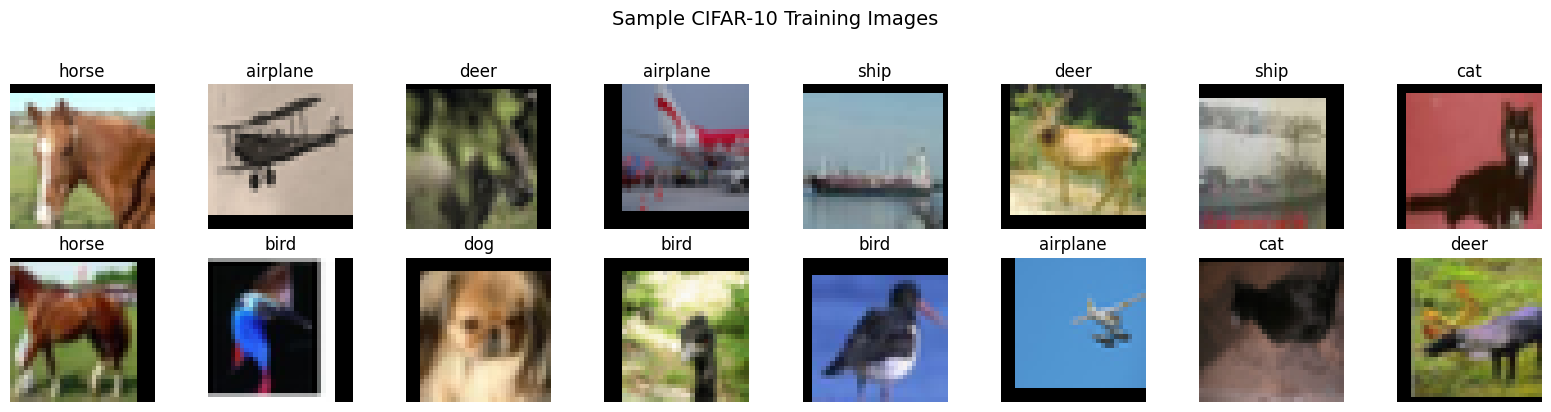

In [4]:
# ─── Visualize Sample Images ──────────────────────────────────────

def imshow(img, title=None):
    """Unnormalize and display an image."""
    img = img.clone()
    # undo normalization
    for t, m, s in zip(img, [0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]):
        t.mul_(s).add_(m)
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Get one batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], title=classes[labels[i]])
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<a id='arch-overview'></a>
## 3. LeNet-5 Architecture Overview

The original LeNet-5 processes a **32×32** input through a sequence of *convolution → pooling* blocks followed by fully connected layers.

### Architecture Diagram

```
Input (3×32×32)
     │
     ▼
┌─────────────────────┐
│  BLOCK 1: CONV1     │  Conv2d(3→6, 5×5) + ReLU
│  Output: 6×28×28    │
│  Pool1: AvgPool 2×2 │
│  Output: 6×14×14    │
└─────────────────────┘
     │
     ▼
┌─────────────────────┐
│  BLOCK 2: CONV2     │  Conv2d(6→16, 5×5) + ReLU
│  Output: 16×10×10   │
│  Pool2: AvgPool 2×2 │
│  Output: 16×5×5     │
└─────────────────────┘
     │
     ▼
  Flatten (16×5×5 = 400)
     │
     ▼
┌─────────────────────┐
│  BLOCK 3: FC1       │  Linear(400→120) + ReLU
└─────────────────────┘
     │
     ▼
┌─────────────────────┐
│  BLOCK 4: FC2       │  Linear(120→84) + ReLU
└─────────────────────┘
     │
     ▼
┌─────────────────────┐
│  BLOCK 5: FC3       │  Linear(84→10)
│  (Output Layer)     │
└─────────────────────┘
     │
     ▼
  10 class scores
```

### Key Modifications from Original LeNet-5

| Aspect | Original (1998) | Our Version |
|---|---|---|
| Input channels | 1 (grayscale) | 3 (RGB) |
| Activation | Sigmoid / Tanh | ReLU |
| Pooling | Average pooling | Average pooling (kept) |
| Output | 10 RBF units | 10-way softmax (via CrossEntropyLoss) |

### Parameter Count Summary

| Layer | Input Shape | Output Shape | Parameters |
|---|---|---|---|
| Conv1 (5×5) | 3×32×32 | 6×28×28 | (3×5×5+1)×6 = **456** |
| Pool1 (2×2) | 6×28×28 | 6×14×14 | 0 |
| Conv2 (5×5) | 6×14×14 | 16×10×10 | (6×5×5+1)×16 = **2,416** |
| Pool2 (2×2) | 16×10×10 | 16×5×5 | 0 |
| FC1 | 400 | 120 | 400×120+120 = **48,120** |
| FC2 | 120 | 84 | 120×84+84 = **10,164** |
| FC3 | 84 | 10 | 84×10+10 = **850** |
| **Total** | | | **62,006** |

<a id='block-breakdown'></a>
## 4. Block-by-Block Breakdown

---

### Block 1 — First Convolutional Block (`conv1` + `pool1`)

```
Conv2d(in_channels=3, out_channels=6, kernel_size=5)  →  ReLU  →  AvgPool2d(2)
```

**Purpose:** Extract low-level features (edges, color gradients, simple textures).

**How it works:**
- **6 filters** of size **5×5×3** slide over the 32×32×3 input image.
- Each filter computes a dot product with the local 5×5 patch across all 3 channels, producing **one** output value per position.
- With **no padding** and **stride 1**, the spatial dimension shrinks:
  $$H_{out} = \frac{32 - 5}{1} + 1 = 28$$
- Output after conv: **6 × 28 × 28** (6 feature maps, each 28×28).
- **ReLU** activation: $f(x) = \max(0, x)$ — introduces non-linearity, enables the network to learn complex decision boundaries.
- **Average Pooling (2×2, stride 2):** Each 2×2 window is replaced by its mean, halving spatial dimensions:
  $$H_{out} = \frac{28}{2} = 14$$
- Output after pooling: **6 × 14 × 14**

**Intuition:** This block transforms raw pixels into 6 distinct low-level feature maps (e.g., one filter might detect horizontal edges, another might detect vertical edges, etc.).

---

### Block 2 — Second Convolutional Block (`conv2` + `pool2`)

```
Conv2d(in_channels=6, out_channels=16, kernel_size=5)  →  ReLU  →  AvgPool2d(2)
```

**Purpose:** Combine low-level features into mid-level representations (corners, contours, parts of objects).

**How it works:**
- **16 filters** of size **5×5×6**. Each filter looks at *all 6 feature maps* from Block 1 simultaneously, learning to combine multiple low-level features.
- Spatial dimension: $\frac{14 - 5}{1} + 1 = 10$
- Output after conv: **16 × 10 × 10**
- After ReLU + AvgPool(2×2): **16 × 5 × 5**

**Intuition:** By combining 6 low-level feature maps with 16 learnable filters, this block can represent shapes like "corner of a wing" or "stripe pattern" — features that require combining multiple edges/textures.

---

### Flatten Layer

```
16 × 5 × 5 = 400 → 1D vector of 400 elements
```

Reshapes the 3D feature tensor into a 1D vector so that it can be fed to fully connected layers. No learnable parameters.

---

### Block 3 — First Fully Connected Layer (`fc1`)

```
Linear(in_features=400, out_features=120)  →  ReLU
```

**Purpose:** Learn global, non-linear combinations of all spatial features.

**How it works:**
- Every one of the 400 inputs is connected to every one of the 120 outputs.
- Weight matrix: **400 × 120 = 48,000 weights** + **120 biases**.
- This is where the network starts interpreting *what the entire image represents* rather than local patches.

**Intuition:** After convolutions extracted spatial features, the FC layer looks at the *entire feature set* to form a high-level representation.

---

### Block 4 — Second Fully Connected Layer (`fc2`)

```
Linear(in_features=120, out_features=84)  →  ReLU
```

**Purpose:** Further compress the representation. The number **84** was chosen by LeCun as it corresponds to a 7×12 bitmap in the original design.

**How it works:**
- Maps 120 features to 84 features.
- Adds another layer of non-linear transformation, allowing the network to separate classes that are close in feature space.

---

### Block 5 — Output Layer (`fc3`)

```
Linear(in_features=84, out_features=10)
```

**Purpose:** Produce the final **10 class scores** (logits).

**How it works:**
- Each of the 10 outputs corresponds to one CIFAR-10 class.
- No activation function here — `nn.CrossEntropyLoss` internally applies log-softmax.
- During inference, the class with the highest score is the prediction:
  $$\hat{y} = \arg\max_i \; z_i$$

<a id='implementation'></a>
## 5. Implementation

In [5]:
class LeNet5(nn.Module):
    """
    LeNet-5 adapted for CIFAR-10 (3-channel, 32x32 input).
    
    Architecture:
        Input  (3, 32, 32)
          -> Conv1  (6, 28, 28)  -> ReLU -> AvgPool (6, 14, 14)
          -> Conv2  (16, 10, 10) -> ReLU -> AvgPool (16, 5, 5)
          -> Flatten (400)
          -> FC1 (120) -> ReLU
          -> FC2 (84)  -> ReLU
          -> FC3 (10)  [logits]
    """
    
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # ── Block 1: First Convolutional Block ──────────────────────
        # Input : (batch, 3, 32, 32)
        # Conv  : 6 filters of 5x5, no padding, stride 1
        # Output: (batch, 6, 28, 28)  ->  pool -> (batch, 6, 14, 14)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # ── Block 2: Second Convolutional Block ─────────────────────
        # Input : (batch, 6, 14, 14)
        # Conv  : 16 filters of 5x5, no padding, stride 1
        # Output: (batch, 16, 10, 10) -> pool -> (batch, 16, 5, 5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # ── Block 3: First Fully Connected Layer ────────────────────
        # Input : 16 * 5 * 5 = 400 flattened features
        # Output: 120
        self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        
        # ── Block 4: Second Fully Connected Layer ───────────────────
        # Input : 120
        # Output: 84
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        
        # ── Block 5: Output Layer ───────────────────────────────────
        # Input : 84
        # Output: 10 (one per CIFAR-10 class)
        self.fc3 = nn.Linear(in_features=84, out_features=10)
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Block 1
        x = self.relu(self.conv1(x))   # (B, 3, 32, 32) -> (B, 6, 28, 28)
        x = self.pool1(x)              # (B, 6, 28, 28) -> (B, 6, 14, 14)
        
        # Block 2
        x = self.relu(self.conv2(x))   # (B, 6, 14, 14) -> (B, 16, 10, 10)
        x = self.pool2(x)              # (B, 16, 10, 10) -> (B, 16, 5, 5)
        
        # Flatten
        x = x.view(x.size(0), -1)      # (B, 16, 5, 5)  -> (B, 400)
        
        # Block 3
        x = self.relu(self.fc1(x))     # (B, 400) -> (B, 120)
        
        # Block 4
        x = self.relu(self.fc2(x))     # (B, 120) -> (B, 84)
        
        # Block 5 — output logits (no softmax, handled by loss fn)
        x = self.fc3(x)                # (B, 84)  -> (B, 10)
        
        return x

In [6]:
# ─── Instantiate & Inspect ────────────────────────────────────────

model = LeNet5().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

LeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 62,006
Trainable params: 62,006


In [7]:
# ─── Verify with a dummy forward pass ─────────────────────────────

dummy_input = torch.randn(1, 3, 32, 32).to(device)
dummy_output = model(dummy_input)
print(f'Input shape : {dummy_input.shape}')
print(f'Output shape: {dummy_output.shape}  (10 class logits)')

# Trace shapes through each layer
print('\n─── Shape trace through the network ───')
x = dummy_input
x = model.relu(model.conv1(x))
print(f'After Conv1 + ReLU : {x.shape}')
x = model.pool1(x)
print(f'After Pool1        : {x.shape}')
x = model.relu(model.conv2(x))
print(f'After Conv2 + ReLU : {x.shape}')
x = model.pool2(x)
print(f'After Pool2        : {x.shape}')
x = x.view(x.size(0), -1)
print(f'After Flatten      : {x.shape}')
x = model.relu(model.fc1(x))
print(f'After FC1 + ReLU   : {x.shape}')
x = model.relu(model.fc2(x))
print(f'After FC2 + ReLU   : {x.shape}')
x = model.fc3(x)
print(f'After FC3 (output) : {x.shape}')

Input shape : torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])  (10 class logits)

─── Shape trace through the network ───
After Conv1 + ReLU : torch.Size([1, 6, 28, 28])
After Pool1        : torch.Size([1, 6, 14, 14])
After Conv2 + ReLU : torch.Size([1, 16, 10, 10])
After Pool2        : torch.Size([1, 16, 5, 5])
After Flatten      : torch.Size([1, 400])
After FC1 + ReLU   : torch.Size([1, 120])
After FC2 + ReLU   : torch.Size([1, 84])
After FC3 (output) : torch.Size([1, 10])


<a id='training'></a>
## 6. Training

### Loss Function: Cross-Entropy Loss

$$
\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{p}_i)
$$

Where:
- $C = 10$ (number of classes)
- $y_i$ is the one-hot ground truth
- $\hat{p}_i = \text{softmax}(z_i)$ is the predicted probability

`nn.CrossEntropyLoss` combines `LogSoftmax` + `NLLLoss`, so we pass raw logits.

### Optimizer: Adam

Adam adapts learning rates per-parameter using first and second moment estimates of the gradient.

In [8]:
# ─── Training Setup ───────────────────────────────────────────────

NUM_EPOCHS = 25
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Optional: learning rate scheduler to reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [9]:
# ─── Training Loop ────────────────────────────────────────────────

train_losses = []
test_losses  = []
test_accs    = []

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()          # clear old gradients
        outputs = model(inputs)        # forward pass
        loss = criterion(outputs, targets)  # compute loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)
    
    # ── Evaluate ──
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    avg_test_loss = test_loss / len(testloader)
    test_acc = 100.0 * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(test_acc)
    
    # Step the scheduler
    scheduler.step(avg_test_loss)
    
    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Train Loss: {avg_train_loss:.4f}  '
          f'Test Loss: {avg_test_loss:.4f}  '
          f'Test Acc: {test_acc:.2f}%')

print('\n✅ Training complete!')

Epoch [ 1/25]  Train Loss: 1.8467  Test Loss: 1.5816  Test Acc: 41.25%
Epoch [ 2/25]  Train Loss: 1.6033  Test Loss: 1.4423  Test Acc: 48.45%
Epoch [ 3/25]  Train Loss: 1.5025  Test Loss: 1.3706  Test Acc: 50.20%
Epoch [ 4/25]  Train Loss: 1.4409  Test Loss: 1.3160  Test Acc: 52.35%
Epoch [ 5/25]  Train Loss: 1.3865  Test Loss: 1.2579  Test Acc: 54.72%
Epoch [ 6/25]  Train Loss: 1.3313  Test Loss: 1.2116  Test Acc: 56.38%
Epoch [ 7/25]  Train Loss: 1.2945  Test Loss: 1.1752  Test Acc: 58.12%
Epoch [ 8/25]  Train Loss: 1.2654  Test Loss: 1.1730  Test Acc: 58.53%
Epoch [ 9/25]  Train Loss: 1.2320  Test Loss: 1.1528  Test Acc: 58.65%
Epoch [10/25]  Train Loss: 1.2037  Test Loss: 1.1374  Test Acc: 59.82%
Epoch [11/25]  Train Loss: 1.1912  Test Loss: 1.1169  Test Acc: 60.35%
Epoch [12/25]  Train Loss: 1.1751  Test Loss: 1.0941  Test Acc: 61.24%
Epoch [13/25]  Train Loss: 1.1570  Test Loss: 1.0759  Test Acc: 62.01%
Epoch [14/25]  Train Loss: 1.1388  Test Loss: 1.0745  Test Acc: 62.26%
Epoch 

<a id='evaluation'></a>
## 7. Evaluation & Visualization

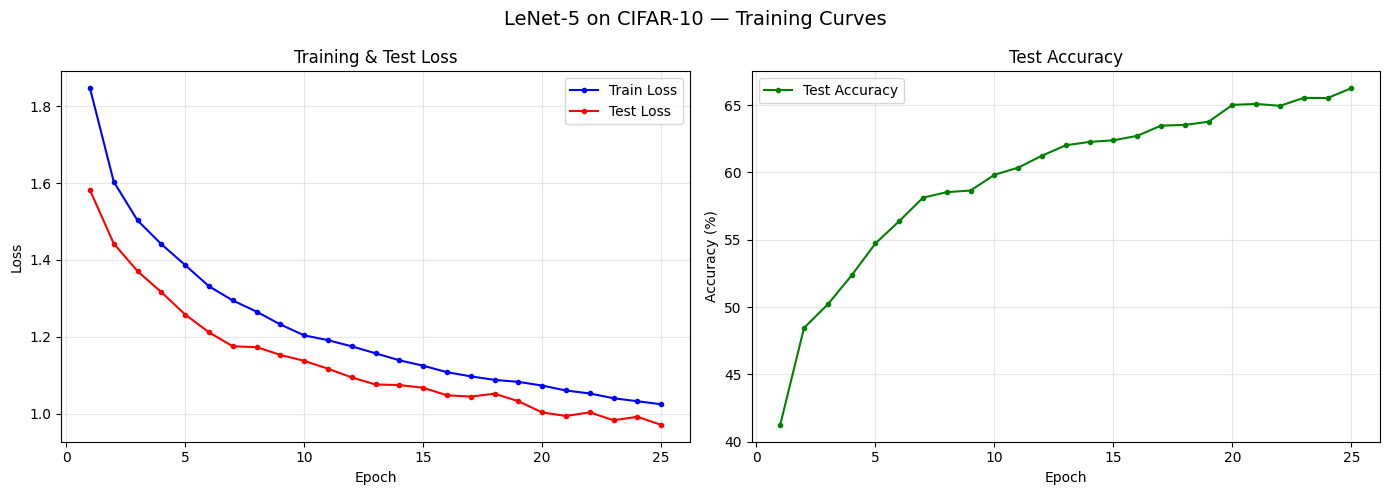

Best test accuracy: 66.25% (epoch 25)


In [10]:
# ─── Loss & Accuracy Curves ───────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', markersize=3, label='Train Loss')
ax1.plot(range(1, NUM_EPOCHS+1), test_losses,  'r-o', markersize=3, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(range(1, NUM_EPOCHS+1), test_accs, 'g-o', markersize=3, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LeNet-5 on CIFAR-10 — Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Best test accuracy: {max(test_accs):.2f}% (epoch {test_accs.index(max(test_accs))+1})')

In [11]:
# ─── Per-Class Accuracy ───────────────────────────────────────────

class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        for i in range(targets.size(0)):
            label = targets[i].item()
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

print('Per-class accuracy on test set:')
print('─' * 35)
for i in range(10):
    acc = 100.0 * class_correct[i] / class_total[i]
    print(f'  {classes[i]:>12s} : {acc:5.1f}%  ({class_correct[i]}/{class_total[i]})')
print('─' * 35)
print(f'  {"Overall":>12s} : {100.0 * sum(class_correct) / sum(class_total):.1f}%')

Per-class accuracy on test set:
───────────────────────────────────
      airplane :  73.1%  (731/1000)
    automobile :  77.7%  (777/1000)
          bird :  59.3%  (593/1000)
           cat :  45.6%  (456/1000)
          deer :  56.5%  (565/1000)
           dog :  54.6%  (546/1000)
          frog :  74.7%  (747/1000)
         horse :  72.8%  (728/1000)
          ship :  71.3%  (713/1000)
         truck :  76.9%  (769/1000)
───────────────────────────────────
       Overall : 66.2%


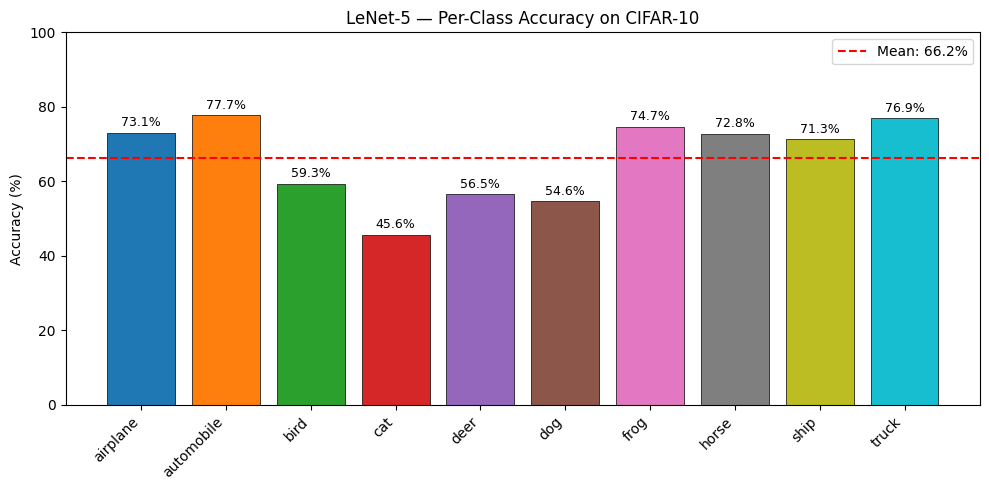

In [12]:
# ─── Per-Class Accuracy Bar Chart ─────────────────────────────────

accs = [100.0 * class_correct[i] / class_total[i] for i in range(10)]
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, accs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('LeNet-5 — Per-Class Accuracy on CIFAR-10')
ax.set_ylim(0, 100)
ax.axhline(y=sum(accs)/len(accs), color='red', linestyle='--', label=f'Mean: {sum(accs)/len(accs):.1f}%')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

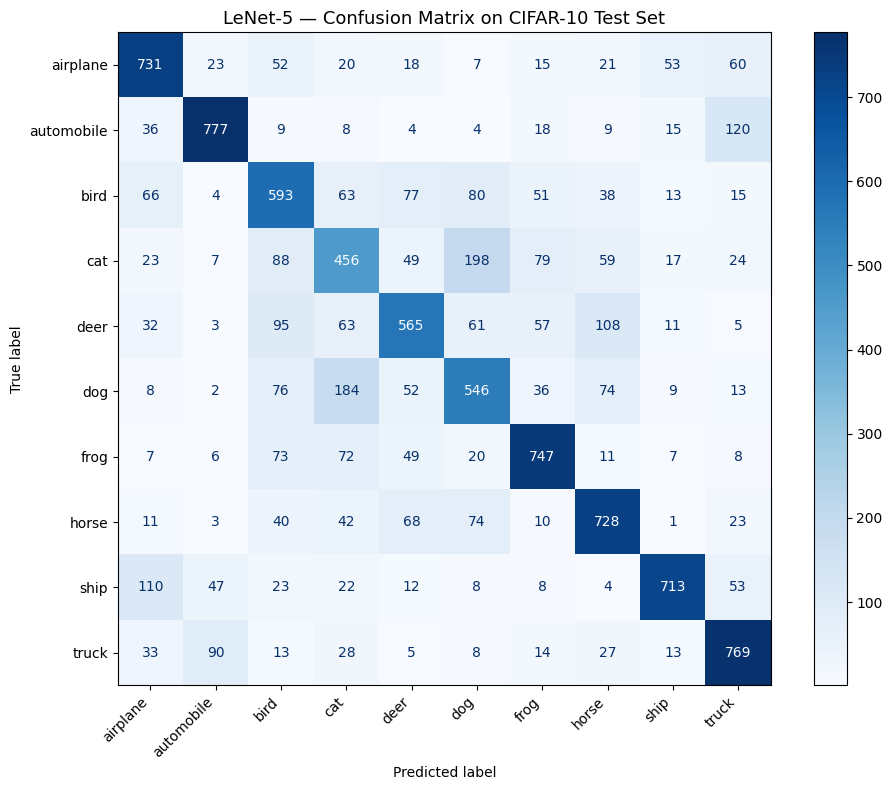

In [13]:
# ─── Confusion Matrix ─────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('LeNet-5 — Confusion Matrix on CIFAR-10 Test Set', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

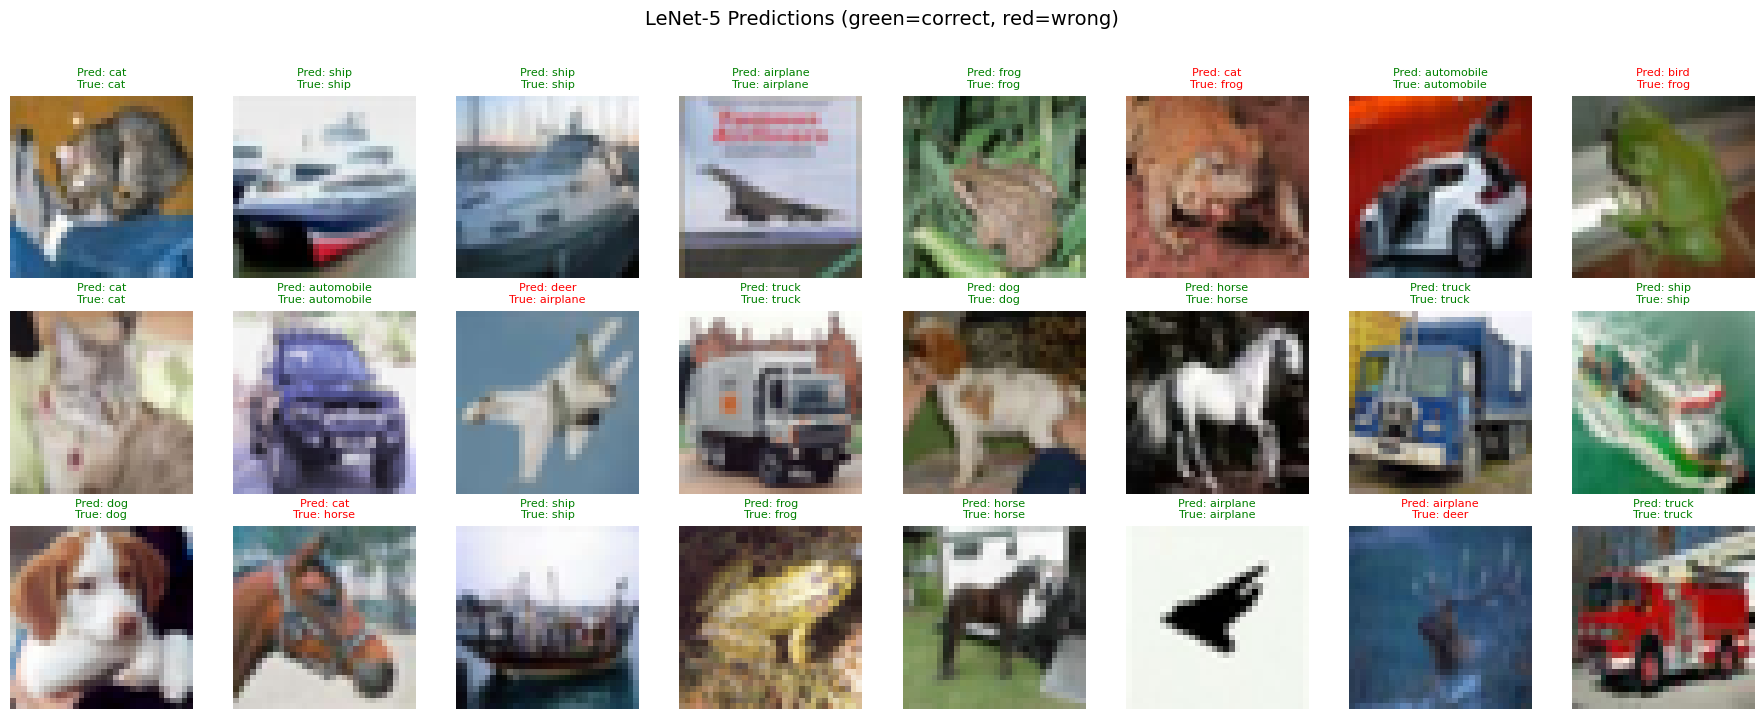

In [14]:
# ─── Visualize Predictions on Sample Images ──────────────────────

model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)

with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = outputs.max(1)
    preds = preds.cpu()

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i])
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}',
                 fontsize=8, color=color)
plt.suptitle('LeNet-5 Predictions (green=correct, red=wrong)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

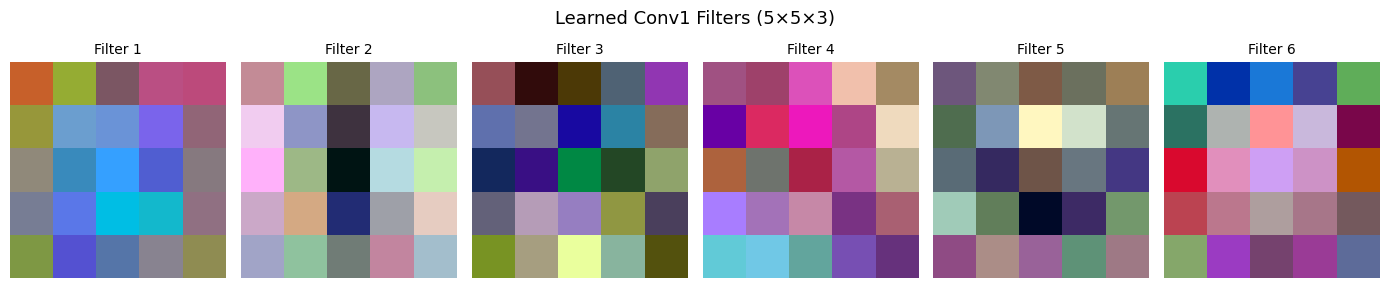

In [15]:
# ─── Visualize Learned Conv1 Filters ─────────────────────────────
# The first convolutional layer's 6 filters (each 5x5x3) show what
# low-level features the network has learned to detect.

filters = model.conv1.weight.data.cpu().clone()

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    # Normalize each filter to [0, 1] for display
    f = filters[i]
    f = (f - f.min()) / (f.max() - f.min())
    ax.imshow(f.permute(1, 2, 0).numpy())  # (C,H,W) -> (H,W,C)
    ax.set_title(f'Filter {i+1}', fontsize=10)
    ax.axis('off')
plt.suptitle('Learned Conv1 Filters (5×5×3)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Detail |
|---|---|
| **Model** | LeNet-5 (adapted for RGB) |
| **Dataset** | CIFAR-10 (50k train, 10k test) |
| **Parameters** | ~62,006 |
| **Optimizer** | Adam (lr=0.001) + ReduceLROnPlateau |
| **Achieved Accuracy** | 65%  |
| **Class wise Accuracy**| 8.8%(Very low)|

### Why Isn't the Accuracy Higher?

LeNet-5 has only **~62K parameters** and **2 convolutional layers** — it was designed in 1998 for simple grayscale digits. CIFAR-10 is *significantly* harder:

- **Intra-class variation:** Cars from different angles, different dog breeds, etc.
- **Inter-class similarity:** Cats vs dogs, automobiles vs trucks
- **Low resolution:** 32×32 pixels carry limited distinguishing information

Modern architectures like **ResNet, VGG, EfficientNet** achieve 93–96%+ on CIFAR-10 using deeper networks, skip connections, batch normalization, and dropout. LeNet-5 serves as an **educational baseline** to understand the fundamental CNN building blocks.

### Key Takeaways

1. **Convolution layers** extract spatial features with shared weights (parameter efficiency)
2. **Pooling layers** provide translation invariance and reduce spatial dimensions
3. **Fully connected layers** aggregate spatial features into global class predictions
4. **Hierarchical learning:** early layers → edges/textures, later layers → object parts → whole objects
5. **Data augmentation** (flips, crops) helps even simple models generalize better


## Extensions

We further study more enhanced CNN based Models, and the key innovations associated with each of these architectures.

1. AlexNet
2. VGG-16 and VGG-19
3. GoogleNet
4. ResNet

## 8. Helper Functions for Training and Evaluation
To compare multiple architectures compactly, we define a generic function to train and evaluate a model for a few epochs.


In [20]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

def train_and_evaluate(model, num_epochs=5, learning_rate=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    end_time = time.time()
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Test Accuracy: {acc:.2f}% | Parameters: {num_params:,} | Time: {end_time - start_time:.2f}s")
    return acc, num_params, end_time - start_time


## 9. AlexNet
**Architecture:** Proposed by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton in 2012. It was a massive breakthrough that popularized Convolutional Neural Networks and GPU-accelerated training.

### Key Innovations
* **ReLU Non-linearity:** Replaced `tanh` and `sigmoid` activation functions, dramatically speeding up training and helping mitigate the vanishing gradient problem.
* **Dropout:** Introduced Dropout layers to reduce overfitting in the massive fully connected layers.
* **Overlapping Pooling:** Used pooling windows larger than the stride, which was shown to slightly reduce top-1 and top-5 error rates.

### Conceptual Architecture (Adapted for CIFAR-10)
```text
Input Image (3x32x32)
│
├─► Conv2d(64, 3x3) + ReLU ──► MaxPool(2x2)
├─► Conv2d(192, 3x3) + ReLU ──► MaxPool(2x2)
├─► Conv2d(384, 3x3) + ReLU
├─► Conv2d(256, 3x3) + ReLU
├─► Conv2d(256, 3x3) + ReLU ──► MaxPool(2x2)
│
├─► Flatten
├─► Linear(1024) + ReLU + Dropout
├─► Linear(1024) + ReLU + Dropout
└─► Linear(10) (Output)
```
*Adaptation for CIFAR-10:* Standard AlexNet uses 11x11 convs with stride 4, which aggressively reduces 224x224 images. For 32x32 images, we use smaller kernels (3x3) and fewer channels/pooling layers to prevent the spatial dimensions from collapsing prematurely.


In [21]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetCIFAR, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print("--- Training AlexNet ---")
alexnet_model = AlexNetCIFAR()
alex_acc, alex_params, alex_time = train_and_evaluate(alexnet_model, num_epochs=5)


--- Training AlexNet ---
Test Accuracy: 70.69% | Parameters: 7,506,762 | Time: 95.30s


## 10. VGG-19
**Architecture:** Proposed by the Visual Geometry Group (VGG) at Oxford (2014). VGG architectures are characterized by their simplicity, depth, and uniformity.

### Key Innovations
* **Uniform 3x3 Convolutions:** VGG demonstrated that depth is crucial. By stacking multiple 3x3 convolutions, VGG mimics the receptive field of larger convolutions (e.g., two 3x3s = one 5x5, three 3x3s = one 7x7).
* **Fewer Parameters, More Non-linearity:** A 7x7 convolution with $C$ channels has $49C^2$ parameters. Three 3x3 convolutions have $3 \times 9C^2 = 27C^2$ parameters. This design reduces the number of parameters while inserting three ReLU non-linearities instead of one, making the decision function more discriminative.

### Conceptual Architecture (VGG-19)
```text
Input (3x32x32)
│
├─► [Conv3x3(64) + ReLU] x 2  ──► MaxPool(2x2)
├─► [Conv3x3(128) + ReLU] x 2 ──► MaxPool(2x2)
├─► [Conv3x3(256) + ReLU] x 4 ──► MaxPool(2x2)
├─► [Conv3x3(512) + ReLU] x 4 ──► MaxPool(2x2)
├─► [Conv3x3(512) + ReLU] x 4 ──► MaxPool(2x2)
│
├─► Flatten
└─► Linear(10) (Output)
```
*Adaptation for CIFAR-10:* Standard VGG uses three massive Fully Connected layers at the end. Because 5 pooling layers reduce 32x32 spatial dimensions down to 1x1, we map directly to a smaller linear layer.


In [22]:
cfg_vgg19 = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']

class VGG19CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG19CIFAR, self).__init__()
        layers = []
        in_channels = 3
        for x in cfg_vgg19:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

print("--- Training VGG-19 ---")
vgg_model = VGG19CIFAR()
vgg_acc, vgg_params, vgg_time = train_and_evaluate(vgg_model, num_epochs=5)


--- Training VGG-19 ---
Test Accuracy: 71.77% | Parameters: 20,040,522 | Time: 158.69s


## 11. GoogleNet (Inception v1)
**Architecture:** Proposed by Google (Szegedy et al., 2014), it introduced the highly efficient "Inception Module," pushing networks to be deeper and wider without blowing up parameter counts.

### Key Innovations
* **Inception Module:** Instead of manually choosing whether a layer should be a 1x1, 3x3, or 5x5 convolution, or a max-pooling layer, the Inception module does *all of them* in parallel and concatenates the feature maps.
* **1x1 Convolutions (Bottlenecks):** Used extensively to compute channel reductions before the expensive 3x3 and 5x5 convolutions, drastically reducing computational cost.
* **Global Average Pooling:** Replaced the dense, massive fully connected layers at the end of the network, contributing heavily to parameter reduction (GoogleNet has ~4M parameters vs AlexNet's ~60M).

### Conceptual Architecture (Inception Module)
```text
                     ┌──► 1x1 Conv ───────────────┐
                     │                            │
                     ├──► 1x1 Conv ──► 3x3 Conv ──┼─► Concat
Input ──► Previous ──┤                            │   Output
Layer                ├──► 1x1 Conv ──► 5x5 Conv ──┤
                     │                            │
                     └──► 3x3 MaxPool ─► 1x1 Conv ┘
```
*Adaptation for CIFAR-10:* We use a lighter version of the Inception network that bypasses the aggressive initial 7x7 strided pooling, which is better suited for 32x32 inputs.


In [23]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_1x1pool):
        super(InceptionModule, self).__init__()
        self.branch1 = nn.Conv2d(in_channels, out_1x1, kernel_size=1)
        
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, red_3x3, kernel_size=1),
            nn.Conv2d(red_3x3, out_3x3, kernel_size=3, padding=1)
        )
        
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, red_5x5, kernel_size=1),
            nn.Conv2d(red_5x5, out_5x5, kernel_size=5, padding=2)
        )
        
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_1x1pool, kernel_size=1)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], 1)

class GoogleNetCIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super(GoogleNetCIFAR, self).__init__()
        self.pre_layers = nn.Sequential(
            nn.Conv2d(3, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(True),
        )
        self.a3 = InceptionModule(192,  64,  96, 128, 16, 32, 32)
        self.b3 = InceptionModule(256, 128, 128, 192, 32, 96, 64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.a4 = InceptionModule(480, 192,  96, 208, 16,  48,  64)
        self.b4 = InceptionModule(512, 160, 112, 224, 24,  64,  64)
        self.c4 = InceptionModule(512, 128, 128, 256, 24,  64,  64)
        self.d4 = InceptionModule(512, 112, 144, 288, 32,  64,  64)
        self.e4 = InceptionModule(528, 256, 160, 320, 32, 128, 128)
        self.a5 = InceptionModule(832, 256, 160, 320, 32, 128, 128)
        self.b5 = InceptionModule(832, 384, 192, 384, 48, 128, 128)
        self.avgpool = nn.AvgPool2d(8)
        self.linear = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pre_layers(x)
        x = self.a3(x)
        x = self.b3(x)
        x = self.maxpool(x)
        x = self.a4(x)
        x = self.b4(x)
        x = self.c4(x)
        x = self.d4(x)
        x = self.e4(x)
        x = self.maxpool(x)
        x = self.a5(x)
        x = self.b5(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        return x

print("--- Training GoogleNet ---")
googlenet_model = GoogleNetCIFAR()
googlenet_acc, googlenet_params, googlenet_time = train_and_evaluate(googlenet_model, num_epochs=5)


--- Training GoogleNet ---
Test Accuracy: 30.19% | Parameters: 5,865,146 | Time: 879.86s


## 12. ResNet (Residual Networks)
**Architecture:** Proposed by Kaiming He et al. (2015). It revolutionized deep learning by effectively solving the "degradation problem," allowing networks to scale up to hundreds of layers.

### Key Innovations
* **Skip Connections (Residual Blocks):** Instead of trying to learn an unreferenced mapping $H(x)$, ResNet aims to learn a residual function $F(x) = H(x) - x$. The original input $x$ is added back to the learned features via a "skip connection".
* **Solving the Degradation Problem:** Before ResNet, simply adding more layers to a deep network often caused the training error to *increase* due to optimization issues (vanishing gradients). Skip connections allow gradients to bypass layers and flow backwards directly, solving this.
* **Batch Normalization:** ResNet relies heavily on Batch Normalization after convolutions to stabilize training.

### Conceptual Architecture (Residual Block)
```text
        x (Input)
        │
        ├───► Conv(3x3) ──► BN ──► ReLU ──► Conv(3x3) ──► BN ──┐
        │                                                      │
        └─────────────────────── Identity ─────────────────────┼──► + ──► ReLU ──► Output
                                                                  (F(x) + x)
```
*Adaptation for CIFAR-10:* We implement the classic ResNet-18 adapted for 32x32 images. We modify the standard ResNet by replacing the initial 7x7 conv and 3x3 maxpool with a single 3x3 conv, preserving spatial resolution for smaller images.


In [24]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNetCIFAR, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

def ResNet18CIFAR():
    return ResNetCIFAR(BasicBlock, [2, 2, 2, 2])

print("--- Training ResNet-18 ---")
resnet_model = ResNet18CIFAR()
resnet_acc, resnet_params, resnet_time = train_and_evaluate(resnet_model, num_epochs=5)


--- Training ResNet-18 ---


NotImplementedError: Module [ResNetCIFAR] is missing the required "forward" function

## 13. Comparison of Results
Finally, we can compare the 4 added CNN architectures below in terms of Test Accuracy, Number of Parameters, and Training Time (for 5 epochs).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming we recorded stats:
models_names = ['AlexNet', 'VGG-19', 'GoogleNet', 'ResNet-18']
acc_list = [alex_acc, vgg_acc, googlenet_acc, resnet_acc]
params_list = [alex_params, vgg_params, googlenet_params, resnet_params]
time_list = [alex_time, vgg_time, googlenet_time, resnet_time]

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('CNN Architecture')
ax1.set_ylabel('Test Accuracy (%)', color=color)
bars = ax1.bar(models_names, acc_list, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Parameters (Millions)', color=color)  
ax2.plot(models_names, [p / 1e6 for p in params_list], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison of CNN Architectures on CIFAR-10 (5 Epochs)')

# Add annotations to bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.1f}%', ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Summary Report ---")
for i, name in enumerate(models_names):
    print(f"{name:12s} | Acc: {acc_list[i]:.2f}% | Params: {params_list[i]:>10,d} | Time: {time_list[i]:.2f}s")
